# Amazon Sales Analysis: Executive Summary

This report looks at sales data from over 1,400 Amazon products to understand what separates highly-rated products from poorly-rated ones, and how factors like price, discounting, and product category relate to customer satisfaction.

The analysis found four key patterns. First, the most popular product category (Electronics) does not have the best customer ratings — in fact, it has the lowest average rating among major categories, while a smaller category (Office Products) has the highest ratings. Second, heavy discounting does not appear to improve customer satisfaction: categories and products with lower discounts often have equal or better ratings than those with steep discounts. Third, higher-priced products tend to receive slightly better ratings than budget products, suggesting a mild link between price and perceived quality. Fourth, and most notably, products with poor ratings (below 3.5) are discounted more heavily on average (58.5%) than top-rated products (43.8%), yet still receive far fewer customer reviews — suggesting discounts alone cannot compensate for weaker product quality.

Together, these findings suggest that discounting strategy should not be used as a substitute for product quality, and that categories with strong reputations (like Office Products) may be under-promoted relative to their customer satisfaction levels. Three actionable recommendations are provided at the end of this report.

## Methodology (Brief)

This analysis uses the Amazon Sales Dataset (1,462 cleaned product records). Data cleaning involved removing currency symbols and converting price/rating fields to numeric types, and dropping rows with missing ratings. To ensure reliable category comparisons, only categories with 20+ products were included in category-level analysis. Correlation, grouping, and distribution analysis were used to identify the patterns discussed below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('amazon.csv')

# Cleaning (jaisa pehle kiya tha)
df['discounted_price'] = df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '', regex=False).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',', '', regex=False).astype(float)
df = df.dropna(subset=['rating', 'rating_count'])
df['main_category'] = df['category'].str.split('|').str[0]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1462 non-null   object 
 1   product_name         1462 non-null   object 
 2   category             1462 non-null   object 
 3   discounted_price     1462 non-null   float64
 4   actual_price         1462 non-null   float64
 5   discount_percentage  1462 non-null   float64
 6   rating               1462 non-null   float64
 7   rating_count         1462 non-null   float64
 8   about_product        1462 non-null   object 
 9   user_id              1462 non-null   object 
 10  user_name            1462 non-null   object 
 11  review_id            1462 non-null   object 
 12  review_title         1462 non-null   object 
 13  review_content       1462 non-null   object 
 14  img_link             1462 non-null   object 
 15  product_link         1462 non-null   object

In [2]:
category_performance = df.groupby('main_category').agg(
    avg_rating=('rating', 'mean'),
    avg_rating_count=('rating_count', 'mean'),
    total_products=('product_id', 'count'),
    avg_price=('discounted_price', 'mean')
).sort_values('avg_rating_count', ascending=False)

category_performance

,avg_rating,avg_rating_count,total_products,avg_price
main_category,,,,
MusicalInstruments,3.900000,44441.000000,2,638.000000
Electronics,4.081749,29997.809886,526,5965.887833
Computers&Accessories,4.155654,17136.782705,451,845.393836
Toys&Games,4.300000,15867.000000,1,150.000000
Home&Kitchen,4.040716,6689.210291,447,2331.133803
OfficeProducts,4.309677,4828.225806,31,301.580645
HomeImprovement,4.250000,4283.000000,2,337.000000
Health&PersonalCare,4.000000,3663.000000,1,899.000000
Car&Motorbike,3.800000,1118.000000,1,2339.000000


In [3]:
reliable_categories = category_performance[category_performance['total_products'] >= 20]
reliable_categories

,avg_rating,avg_rating_count,total_products,avg_price
main_category,,,,
Electronics,4.081749,29997.809886,526,5965.887833
Computers&Accessories,4.155654,17136.782705,451,845.393836
Home&Kitchen,4.040716,6689.210291,447,2331.133803
OfficeProducts,4.309677,4828.225806,31,301.580645


In [4]:
category_performance2 = df.groupby('main_category').agg(
    avg_rating=('rating', 'mean'),
    avg_rating_count=('rating_count', 'mean'),
    total_products=('product_id', 'count'),
    avg_price=('discounted_price', 'mean'),
    avg_discount=('discount_percentage', 'mean')
).query('total_products >= 20').sort_values('avg_discount', ascending=False)

category_performance2

,avg_rating,avg_rating_count,total_products,avg_price,avg_discount
main_category,,,,,
Computers&Accessories,4.155654,17136.782705,451,845.393836,53.920177
Electronics,4.081749,29997.809886,526,5965.887833,50.828897
Home&Kitchen,4.040716,6689.210291,447,2331.133803,40.174497
OfficeProducts,4.309677,4828.225806,31,301.580645,12.354839


In [5]:
df['price_range'] = pd.cut(df['discounted_price'], 
                             bins=[0, 500, 2000, 10000, 100000], 
                             labels=['Budget (<500)', 'Mid (500-2000)', 'Premium (2000-10000)', 'Luxury (10000+)'])

price_analysis = df.groupby('price_range', observed=True).agg(
    avg_rating=('rating', 'mean'),
    avg_rating_count=('rating_count', 'mean'),
    total_products=('product_id', 'count')
)

price_analysis

,avg_rating,avg_rating_count,total_products
price_range,,,
Budget (<500),4.074739,17040.677700,574
Mid (500-2000),4.092789,21516.068311,527
Premium (2000-10000),4.107950,15379.075314,239
Luxury (10000+),4.195082,16143.188525,122


In [6]:
top_rated = df[df['rating'] >= 4.5]
low_rated = df[df['rating'] < 3.5]

print("Top Rated Products (4.5+):")
print(f"Count: {len(top_rated)}")
print(f"Average Discount %: {top_rated['discount_percentage'].mean():.1f}%")
print(f"Average Price: ₹{top_rated['discounted_price'].mean():.2f}")
print(f"Average Rating Count: {top_rated['rating_count'].mean():.0f}")

print("\nLow Rated Products (<3.5):")
print(f"Count: {len(low_rated)}")
print(f"Average Discount %: {low_rated['discount_percentage'].mean():.1f}%")
print(f"Average Price: ₹{low_rated['discounted_price'].mean():.2f}")
print(f"Average Rating Count: {low_rated['rating_count'].mean():.0f}")

Top Rated Products (4.5+):
Count: 103
Average Discount %: 43.8%
Average Price: ₹2532.52
Average Rating Count: 15428

Low Rated Products (<3.5):
Count: 41
Average Discount %: 58.5%
Average Price: ₹905.17
Average Rating Count: 2249


In [7]:
plt.style.use('seaborn-v0_8')

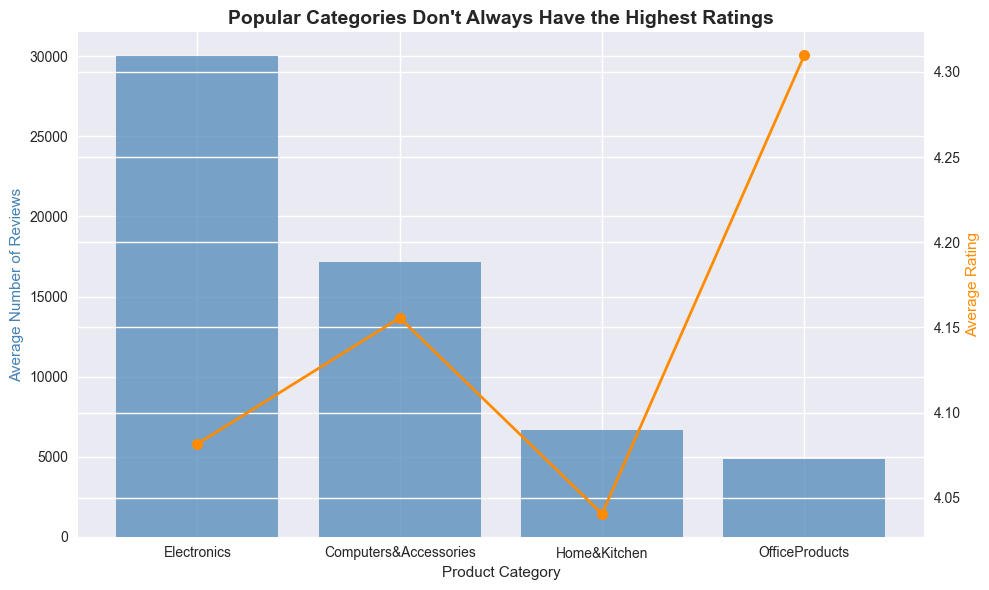

In [8]:
fig, ax1 = plt.subplots(figsize=(10,6))

categories = reliable_categories.index
x = range(len(categories))

ax1.bar(x, reliable_categories['avg_rating_count'], color='steelblue', alpha=0.7, label='Avg. Number of Reviews')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Average Number of Reviews', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)

ax2 = ax1.twinx()
ax2.plot(x, reliable_categories['avg_rating'], color='darkorange', marker='o', linewidth=2, markersize=8, label='Avg. Rating')
ax2.set_ylabel('Average Rating', color='darkorange')

plt.title('Popular Categories Don\'t Always Have the Highest Ratings', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### Finding 1: Electronics is the Most Popular Category, But Has the Lowest Rating
Electronics receives the highest average number of reviews (29,997) by a wide margin, yet has the lowest average rating (4.08) among reliable categories. Office Products shows the opposite pattern — far fewer reviews, but the highest rating (4.31). This suggests that popularity and customer satisfaction are not the same thing.

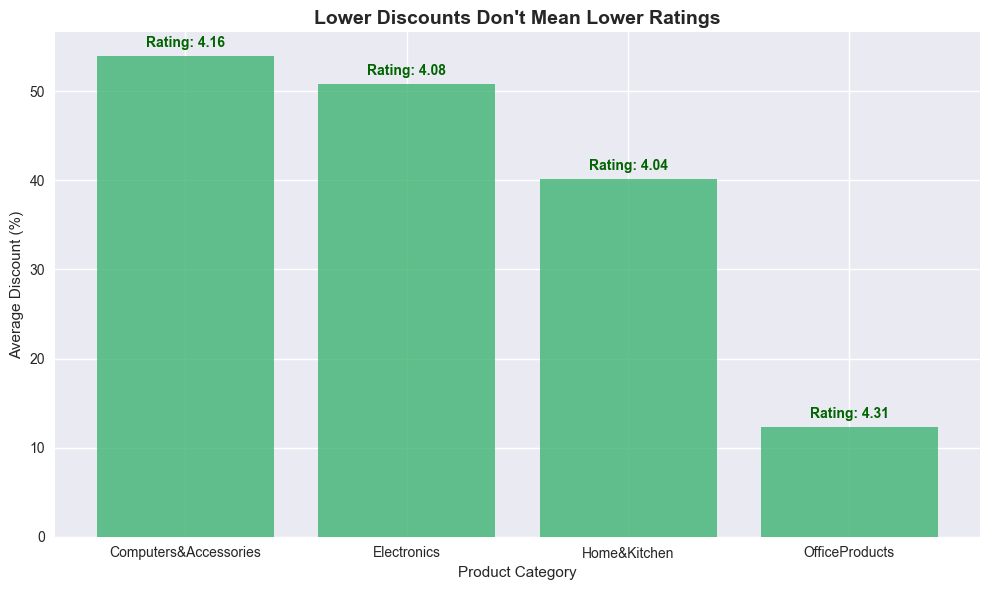

In [9]:
fig, ax = plt.subplots(figsize=(10,6))

categories = category_performance2.index
x = range(len(categories))

bars = ax.bar(x, category_performance2['avg_discount'], color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Product Category')
ax.set_ylabel('Average Discount (%)')
ax.set_xticks(x)
ax.set_xticklabels(categories)

# Har bar ke upar rating value likh dete hain
for i, (discount, rating) in enumerate(zip(category_performance2['avg_discount'], category_performance2['avg_rating'])):
    ax.text(i, discount + 1, f'Rating: {rating:.2f}', ha='center', fontsize=10, fontweight='bold', color='darkgreen')

plt.title('Lower Discounts Don\'t Mean Lower Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Finding 2: Lower Discounts Don't Mean Lower Ratings
Office Products has the lowest average discount (12.4%) of all reliable categories, yet the highest rating (4.31). Categories offering much steeper discounts (40-54%) actually have slightly lower ratings. This indicates heavy discounting is not necessary to achieve strong customer satisfaction.

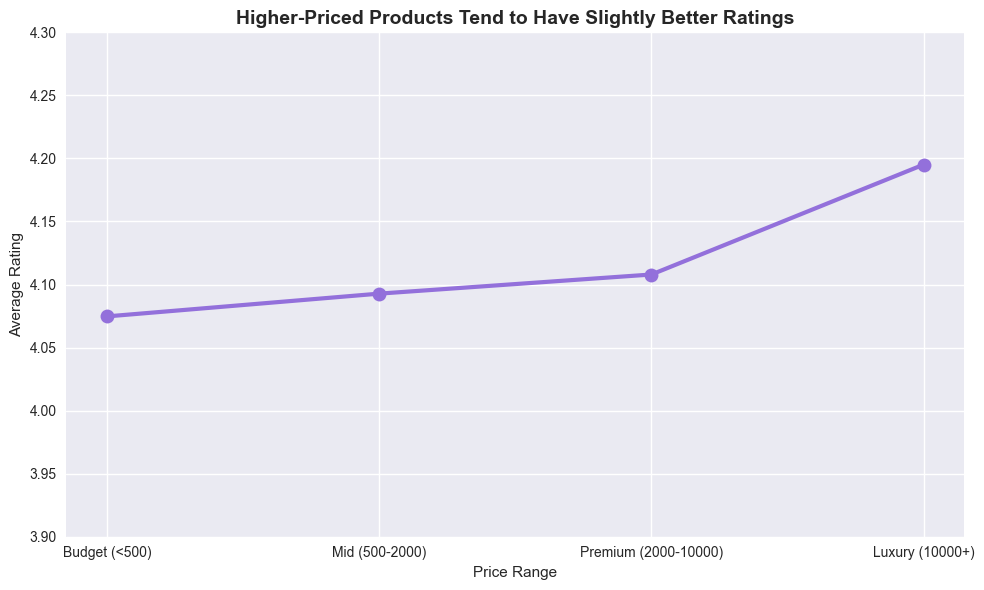

In [10]:
fig, ax = plt.subplots(figsize=(10,6))

price_order = ['Budget (<500)', 'Mid (500-2000)', 'Premium (2000-10000)', 'Luxury (10000+)']
ratings = price_analysis.loc[price_order, 'avg_rating']

ax.plot(price_order, ratings, marker='o', linewidth=3, markersize=10, color='mediumpurple')
ax.set_xlabel('Price Range')
ax.set_ylabel('Average Rating')
ax.set_ylim(3.9, 4.3)

plt.title('Higher-Priced Products Tend to Have Slightly Better Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Finding 3: Higher-Priced Products Tend to Have Slightly Better Ratings
Average rating increases consistently across price tiers, from 4.07 for budget products (under ₹500) to 4.20 for luxury products (₹10,000+). While the difference is modest, it suggests a mild link between price and perceived product quality.

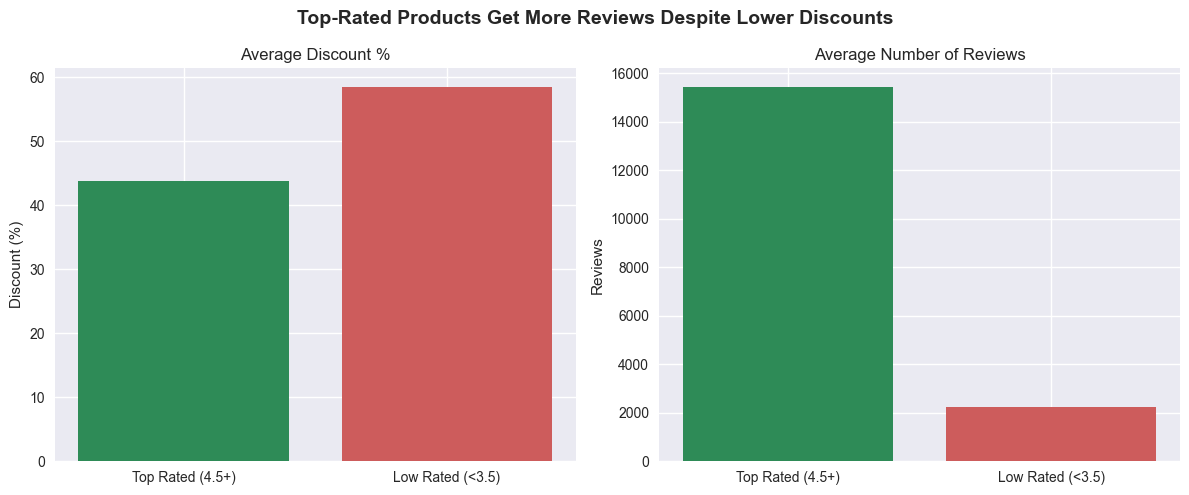

In [11]:
comparison_data = pd.DataFrame({
    'Discount %': [top_rated['discount_percentage'].mean(), low_rated['discount_percentage'].mean()],
    'Avg Rating Count': [top_rated['rating_count'].mean(), low_rated['rating_count'].mean()]
}, index=['Top Rated (4.5+)', 'Low Rated (<3.5)'])

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(comparison_data.index, comparison_data['Discount %'], color=['seagreen', 'indianred'])
axes[0].set_title('Average Discount %')
axes[0].set_ylabel('Discount (%)')

axes[1].bar(comparison_data.index, comparison_data['Avg Rating Count'], color=['seagreen', 'indianred'])
axes[1].set_title('Average Number of Reviews')
axes[1].set_ylabel('Reviews')

plt.suptitle('Top-Rated Products Get More Reviews Despite Lower Discounts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Finding 4: Poorly-Rated Products Are Discounted More Heavily, Yet Get Fewer Reviews
Products rated below 3.5 carry a higher average discount (58.5%) than products rated 4.5 and above (43.8%). Despite this, low-rated products receive far fewer customer reviews on average (2,249 vs 15,428). This suggests discounts alone cannot compensate for weaker product quality or drive meaningful engagement.

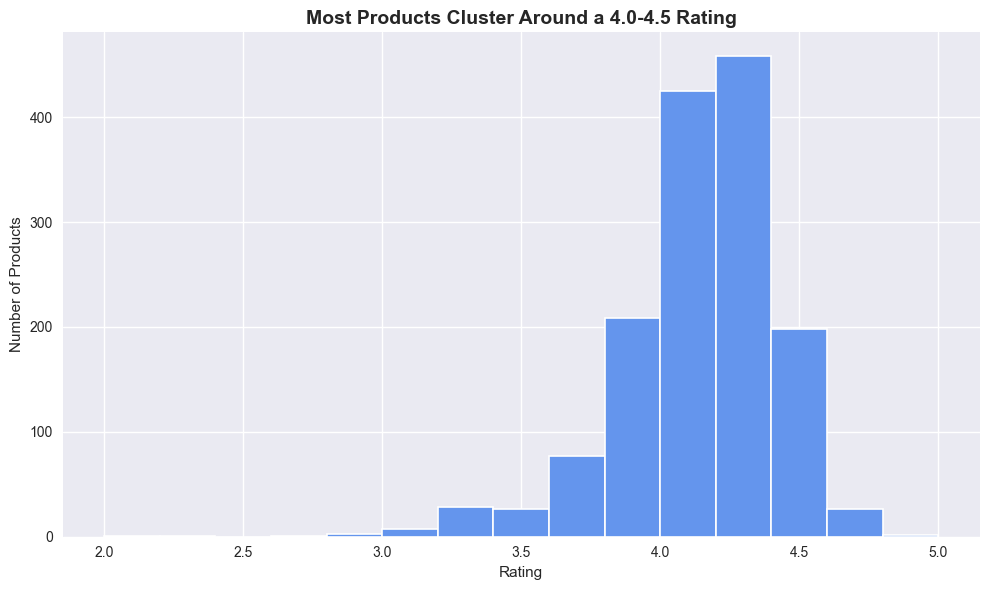

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(df['rating'], bins=15, color='cornflowerblue', edgecolor='white', linewidth=1.2)
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Products')

plt.title('Most Products Cluster Around a 4.0-4.5 Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Overall Context
Across the full dataset, most products cluster between a 4.0 and 4.5 rating, showing that overall customer sentiment is generally positive. This provides useful context for interpreting the findings above — even "low-rated" categories are not performing badly in absolute terms, but relatively worse compared to top performers.

## Recommendations

1. **Don't rely on discounts alone to drive satisfaction.** Since low-rated products already carry higher average discounts (58.5%) without improving customer perception, the business should invest in product quality improvements or better supplier vetting rather than deeper discounting for underperforming categories.

2. **Promote Office Products more aggressively.** This category has the highest average rating (4.31) and lowest discount dependency (12.4%), yet receives the fewest reviews of the reliable categories. Increasing marketing visibility for this category could convert its strong reputation into higher sales volume.

3. **Investigate what drives Electronics' lower ratings despite high popularity.** Since Electronics is the most reviewed category but has the lowest average rating, a focused review of common complaints (e.g. through customer review text analysis) could identify quick wins to improve satisfaction in the business's most visible category.